* You can add as many cells as you need to answer the questions.
* You can also answer any word or math based questions in a markup cell.
* Plots should have labels on the axes, legends if appropriate etc.

# Assignment 1 :  MC Simulations of Estimators of Location and Spread

In [1]:
import numpy as np
import scipy.stats

import matplotlib
import matplotlib.pyplot as plt

# Adjust default font size so that labels are readable in plots
font = {'size': 12}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.figsize'] = [6, 4]
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

For full marks, write the code below as a function or suite of functions that accepts another function (e.g. one that calculates $s^2$ or $s$) as an argument.

## Q1

For the first exercise you will use ``numpy`` and/or ``scipy`` and/or your own functions to test the formula for the estimated sample variance $s^2$.  

1. Do a _Monte Carlo_ (MC) simulation by drawing $M$ samples of $N$ data points, where $M$ is some very large number (like 10000). Each sample of $N$ data points is drawn from a Gaussian distribution with mean $\mu = 0$ and $\sigma^2 = 1$.

2. For each sample, <mark>calculate the _sample_ variance $s^2$</mark> using the standard formula. 
<mark>You can use builtin functions to do this on numpy arrays, or write your own. If the former, read the function docs carefully.</mark>

3. <mark>Save the values of $s^2$ in an array of length $M$</mark>. We are using a MC method to estimate what is called the _sampling distribution_, or, more specifically, the _sampling distribution of the sample variance_.

4. Then <mark>calculate the mean and variance of $s^2$ over all the $M$ MC samples</mark>, i.e the mean and variance of the sampling distribution.

5. Plot the mean $s^2$ (over all $M$ MC samples), $\overline{s^2}$, along with errorbars that show the <mark>_standard error_ in $\overline{s^2}$ (not the standard deviation of $s^2$)</mark>, as a function of $N$ from $N = 2$ to $N = 30$. Plot a line showing the <mark>expected value of $s^2$ for the population</mark>.

6. What is the $\chi^2$ of the simulated data points plotted in 5) compared to the model line? <mark>Is it an acceptable fit?</mark>

7. Based on this Monte Carlo experiment, is the sample variance estimator ($s^2$) unbiased?


### Step 1

In [2]:
def compute_variance_of_sample(data):
    variance = np.var(data, ddof=1)         # ddof = 1 because we are estimating the mean from the data (N-1 factor)
    
    return variance

def estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(function_that_computes_metric, M, N, rng):
    estimates_for_each_sample = np.empty(shape=M)

    for i in range(0,M):
        sample = rng.normal(loc=0,scale=1,size=N)            # N(mu=0,std=1)
        estimates_for_each_sample[i] = function_that_computes_metric(sample)

    return estimates_for_each_sample

def compute_standard_error_of_sample(sample_variance, N):
    standard_error = np.sqrt(sample_variance / N)

    return standard_error

def compute_chi2_of_data(data, model, uncertainty):
    chi2 = np.sum( ( (data - model)/(uncertainty) )**2 )

    return chi2  

def compute_reduced_chi2(chi2, dof):
    rdchi2 = chi2 / dof
    
    return rdchi2   


In [3]:
M = 10000       # Number of samples to be drawn, we draw M times a sample containing N data points taken from N~N(0,1)
N_array = np.linspace(2, 30, num=29, dtype=int)

rng = np.random.default_rng()

### Step 2 and 3 

In [4]:
estimates_of_variance = []          # holds the variances estimated by each individual 10000 runs with N data points, for each N                            # shape (29, 10000)

for N in N_array:
    variance_estimates = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_variance_of_sample, M, N, rng)      # shape (10000,), contains 10000 variance values for a given N 
    estimates_of_variance.append(variance_estimates)

print(estimates_of_variance)        # array of 10000 s2 values for each N

[array([2.11114718, 0.16017791, 0.01315993, ..., 0.02077377, 0.68403626,
       2.06316097], shape=(10000,)), array([1.21048084, 0.7319244 , 1.30124888, ..., 1.37205892, 0.48932999,
       0.36001331], shape=(10000,)), array([1.27949333, 1.23317654, 0.36431388, ..., 0.42182743, 0.25881628,
       0.35370368], shape=(10000,)), array([1.01036028, 0.27297551, 0.81094601, ..., 0.25096585, 3.15060218,
       0.74270509], shape=(10000,)), array([0.49560517, 1.72276357, 1.55652246, ..., 0.94915169, 1.32462428,
       2.06569767], shape=(10000,)), array([0.61410334, 1.3453718 , 0.81613907, ..., 1.37039892, 1.12772708,
       0.57139106], shape=(10000,)), array([0.8615927 , 0.44608354, 1.27944016, ..., 0.64653881, 1.75913748,
       0.67078808], shape=(10000,)), array([0.57738442, 1.4124911 , 0.51602159, ..., 2.14453168, 1.16743547,
       0.70379847], shape=(10000,)), array([0.97484399, 0.52300195, 0.97298944, ..., 2.12678425, 0.56894117,
       1.52135088], shape=(10000,)), array([0.60434518,

### Step 4

In [5]:
means_of_estimates_of_variance = []      # holds the mean of all 10000 variances computed for a given N                  # shape (29, 1)
for estimates in estimates_of_variance: 
    mean = np.mean(estimates)           # computes the mean of all 10000 variances          # shape (1,)
    means_of_estimates_of_variance.append(mean)   

variances_of_estimates_of_variance = []  # holds the variance of all the 10000 variances computed for a given N          # shape (29, 1)
for estimates in estimates_of_variance:
    var = np.var(estimates, ddof=1)                 # Bessel Correction Factor
    variances_of_estimates_of_variance.append(var)

print(means_of_estimates_of_variance)            # array of the avg of all 10000 s2 values for a given N     
print()
print(variances_of_estimates_of_variance)        # array of the s2 of all 10000 s2 values for a given N 

[np.float64(1.000477508360703), np.float64(0.9885277801359167), np.float64(1.0054761026965011), np.float64(0.9968326971520525), np.float64(0.9885357835037614), np.float64(1.0001210027386498), np.float64(1.010096498745054), np.float64(1.0015167293837735), np.float64(0.9976744289416918), np.float64(0.9986083586823843), np.float64(0.9969499696253737), np.float64(0.9992403359144891), np.float64(0.9980853776841874), np.float64(1.0047946950732802), np.float64(0.9970512257576806), np.float64(0.9994387091989353), np.float64(0.9968369241960214), np.float64(1.0020144922814227), np.float64(1.0021943029372946), np.float64(1.0052500139062672), np.float64(0.9976275056398023), np.float64(1.004229841760811), np.float64(0.9980295688141682), np.float64(0.9942974350923561), np.float64(0.9999186954500409), np.float64(1.002987320343977), np.float64(0.9983637607704695), np.float64(1.000429688030408), np.float64(1.003002698166408)]

[np.float64(1.9175887754060512), np.float64(0.9885550287663873), np.float64(

### Step 5

standard error in the mean is:

$$
\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}} = \sqrt{ \frac{\sigma^2}{N} }
$$

but the population variance $\sigma^2$ is unknown, so we estimate the standard error by substituting the sample variance $s^2$

\begin{equation*}
    \sigma_{\bar{x}} = \sqrt{ \frac{s^2}{N} }
\end{equation*}

so that the standard error of the mean variance with M sample size is 

\begin{equation*}
    \sigma_{\bar{s^2}} = \sqrt{ \frac{\rm var(s^2)}{M} }
\end{equation*}

In [6]:
standard_errors_of_means_of_estimates_of_variance = []              # holds the stderr for each mean        # shape (29, 1)

for var in variances_of_estimates_of_variance:
    stderr = compute_standard_error_of_sample(var, N=M)             # computes the std err in the mean of the variances -> we computed the avg of all 10000 s2 values so N=10000
    standard_errors_of_means_of_estimates_of_variance.append(stderr)

print(standard_errors_of_means_of_estimates_of_variance)            # array of stderr for each mean of variance     # shape (29 , 1)

[np.float64(0.01384770296982879), np.float64(0.00994261046590073), np.float64(0.008171822188502757), np.float64(0.006948120057603654), np.float64(0.006316505304775782), np.float64(0.005767574192606257), np.float64(0.005358626113662554), np.float64(0.004949401454399626), np.float64(0.004674267233389148), np.float64(0.0044251581124735715), np.float64(0.004294783713094442), np.float64(0.004108136357983864), np.float64(0.003892372722690537), np.float64(0.003762089726673532), np.float64(0.003664628694922426), np.float64(0.0035768981133722892), np.float64(0.003418142060149324), np.float64(0.0032523782652760275), np.float64(0.003279184938288184), np.float64(0.003171154421720053), np.float64(0.0030386206301844334), np.float64(0.00304680689671897), np.float64(0.0029369651892442177), np.float64(0.0029052281863155434), np.float64(0.0028092372576081132), np.float64(0.0027915854576434094), np.float64(0.0026987945203028655), np.float64(0.0026734327054344065), np.float64(0.0026648923090262663)]


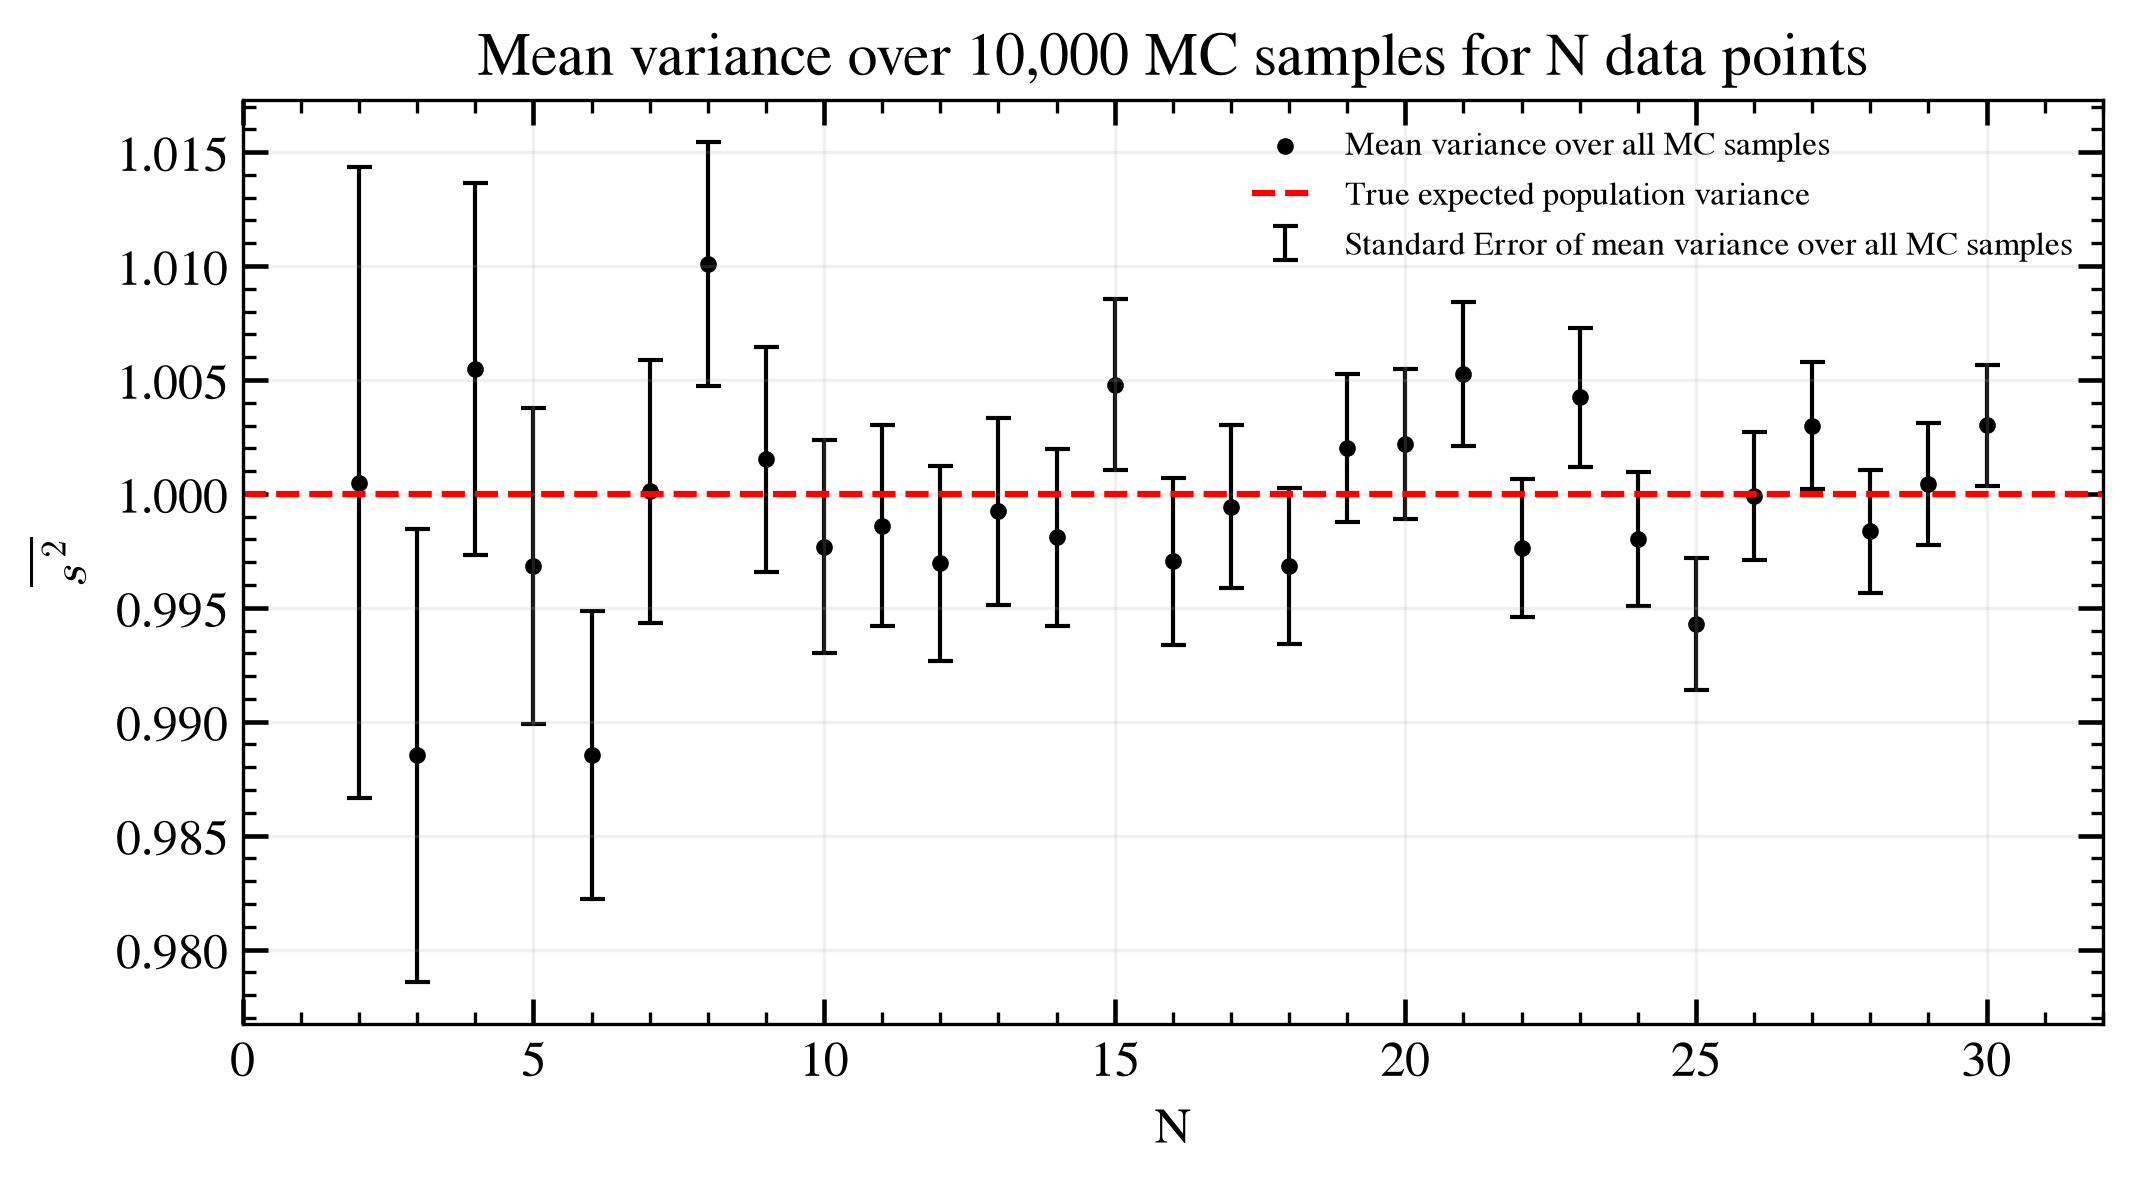

In [7]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('N')
ax.set_ylabel(r'$\overline{s^2}$')
ax.set_title("Mean variance over 10,000 MC samples for N data points")
ax.set_xlim(0,32)
# ax.set_ylim(0.95,1.05)

ax.scatter(N_array, means_of_estimates_of_variance, marker='.', label="Mean variance over all MC samples", color='black')

ax.errorbar(N_array, means_of_estimates_of_variance, 
    yerr=standard_errors_of_means_of_estimates_of_variance,
    fmt="none",
    capsize=3,
    lw = 1.0, 
    label="Standard Error of mean variance over all MC samples",
    zorder= -3, 
    color = 'black'
)

ax.axhline(y=1, color= 'red', ls='dashed', label = 'True expected population variance')    # true E[s2] for normal ~N(0,1) is 1

ax.legend(frameon=False, fontsize=8, loc='best')

### Step 6

The $\chi^2$ relative to y = 1 is given by 

\begin{equation*}

\chi^2 = \sum_i^N \frac{(y_i - f_i)^2}{\sigma_i^2}

\end{equation*}
where $y_i$ is measured and $f_i$ is the model, $\sigma_i$ is the uncertainty in $y_i$. 

In our case, $y_i = \overline{s^2}$ , $f_i = 1$, and $\sigma_i=$ standard error of $\overline{s^2}$

\begin{equation*}

\chi^2 = \sum_2^{30} \bigg( \frac{\overline{s^2} - 1}{SE[\overline{s^2}]} \bigg)^2

\end{equation*}

In [8]:
data = np.asarray(means_of_estimates_of_variance)
model = np.ones_like(data)
unc = np.asarray(standard_errors_of_means_of_estimates_of_variance)

chi2_of_means_of_estimates_of_variance = compute_chi2_of_data(data,model,unc)           #gives a singular chi2 value for the fit to the data

dof = len(N_array) - 0                   # dof = N - numbers of parameters = 29 since we have 29 data points and no parameters (model is a constant)

print(f"chi2: {chi2_of_means_of_estimates_of_variance}")
print(f"reduced chi2: {compute_reduced_chi2(chi2_of_means_of_estimates_of_variance, dof=dof)}")        

pval = scipy.stats.chi2.sf(chi2_of_means_of_estimates_of_variance, dof)
print(f"p value: {pval}") 


chi2: 26.428709065274795
reduced chi2: 0.9113347953543033
p value: 0.6024978310839093


In [9]:
# Goodness of fit
if pval < 0.05:         # reject H0 that data and model are the same
    print(f'This is not a good fit. With a p = {pval:2f} < 0.05, we must reject the prediction that the data and the model are equal.')

if pval >= 0.05:         # reject H0 that data and model are the same
    print(
        f'This is a good fit. With a p = {pval:2f} >= 0.05, we do not have enough evidence to reject the prediction that the data and the model are equal.' ,
        f'\nThus we can say this is a statistically acceptable fit and that the simulated results are consistent with it.'
    )

This is a good fit. With a p = 0.602498 >= 0.05, we do not have enough evidence to reject the prediction that the data and the model are equal. 
Thus we can say this is a statistically acceptable fit and that the simulated results are consistent with it.


### Step 7

Given that the MC mean of the sample variance is consistent with the true population variance of $1$ across $N = 2,3,...,30$ sample sizes and that the chi-squared did not yield any significant disagreement with this prediction, I claim that based on this MC experiment that the estimator is <b>unbiased</b> since its measured metric averaged over a large sample size did not deviate from the true population value. 

## Q2

In a variant of the above exercises, suppose for each sample of size $N$ drawn from a normal distribution, you calculate both the _sample_ mean $\bar{x}$ and the _sample_ variance $s^2$. Then define the statistic:
$$
Z = \frac{\bar{x}}{s/\sqrt{N}}
$$

a) For $N=5$, $M = 100,000$, plot a histogram of $Z$. Overplot a normal distribution.

b) Repeat for $N=100$.


c)  Is it the overplotted normal distribution [in parts a) and b)] a good fit? If not, why and in what way does it differ?

### Part a)

In [10]:
N = 5
M = 100000

def compute_Z(data):
    sample_mean = np.mean(data)
    sample_variance = compute_variance_of_sample(data)
    N = len(data)
    
    Z = sample_mean / (np.sqrt(sample_variance / N))

    return Z

In [11]:
Z_estimates_for_N_5 = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_Z, M=M, N=N, rng=rng)       # array of 100000 Z values for N = 5

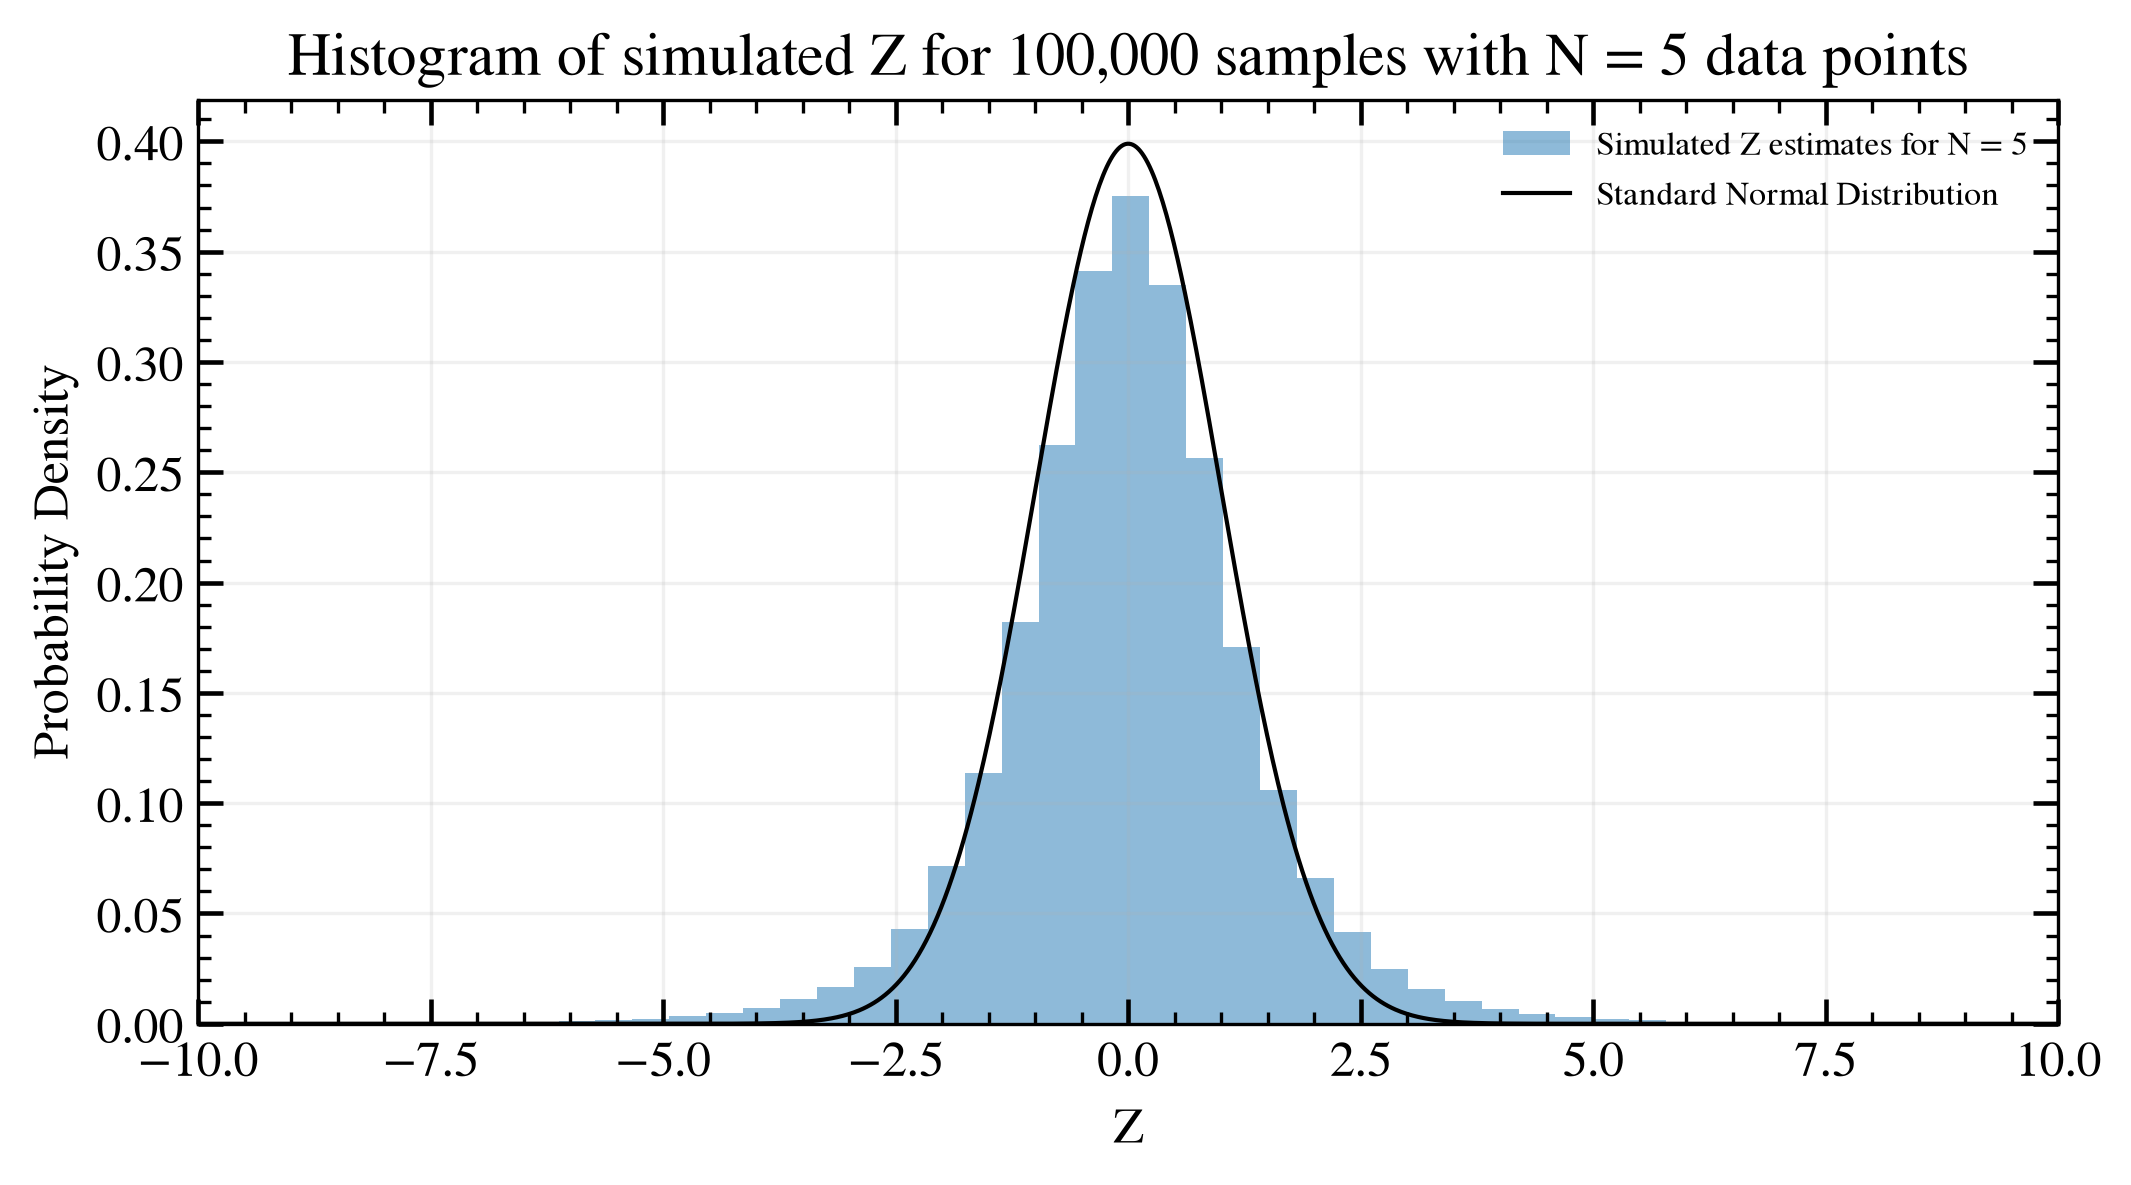

In [12]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

z_space = np.linspace(-10,10,1000)
N01 = scipy.stats.norm.pdf(z_space, loc=0, scale=1)       # Normal distr with mu = 0 and std = 1

ax.hist(Z_estimates_for_N_5, density=True, histtype='stepfilled', alpha=0.5, label='Simulated Z estimates for N = 5', bins=200)
ax.plot(z_space, N01, 'k-', lw=1, label='Standard Normal Distribution')

ax.set_xlabel('Z')
ax.set_ylabel('Probability Density')
ax.set_title("Histogram of simulated Z for 100,000 samples with N = 5 data points")
ax.set_xlim(z_space[0],z_space[-1])
# ax.set_ylim(0,1)
ax.legend(frameon=False, fontsize=8, loc='best')

### Part b)

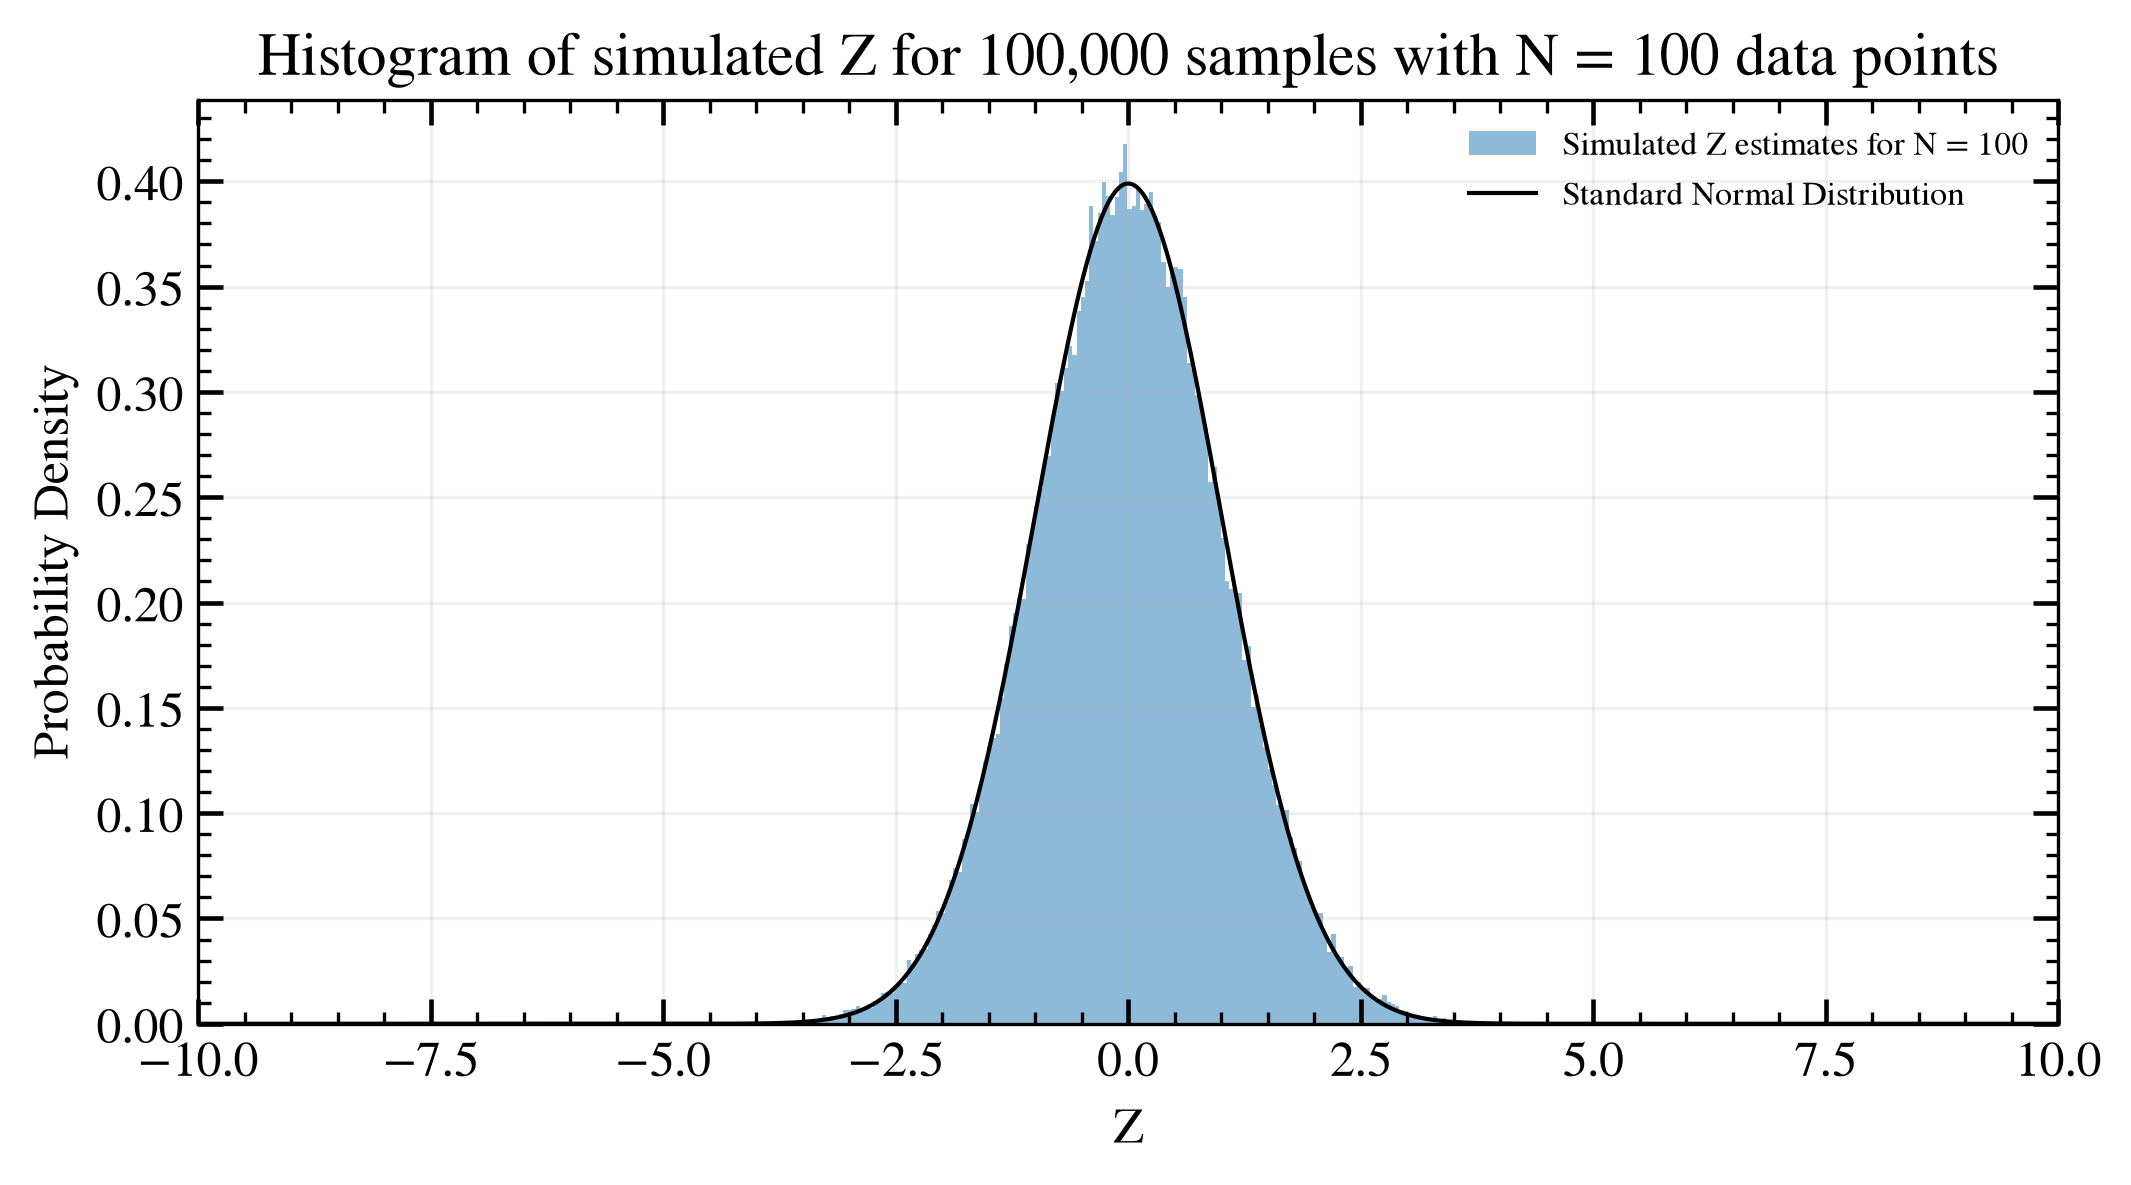

In [13]:
N = 100
M = 100000

Z_estimates_for_N_100 = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_Z, M=M, N=N, rng=rng)       # array of 100000 Z values for N = 100

import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

z_space = np.linspace(-10,10,1000)
N01 = scipy.stats.norm.pdf(z_space, loc=0, scale=1)       # Normal distr with mu = 0 and std = 1

ax.hist(Z_estimates_for_N_100, density=True, histtype='stepfilled', alpha=0.5, label='Simulated Z estimates for N = 100', bins=200)
ax.plot(z_space, N01, 'k-', lw=1, label='Standard Normal Distribution')

ax.set_xlabel('Z')
ax.set_ylabel('Probability Density')
ax.set_title("Histogram of simulated Z for 100,000 samples with N = 100 data points")
ax.set_xlim(z_space[0],z_space[-1])
# ax.set_ylim(0,1)
ax.legend(frameon=False, fontsize=8, loc='best')

### Part c)

I would say that in part a), the overplotted normal distribution is <b>not a good fit</b>. This is because it overestimates the probability density near the peak at zero and underestimates the probability density in the tails away from $z = 0$. The reason for this is because the denominator uses the estimated standard deviation $s$ such that the statistic follows Student’s $t$-distribution with $N-1$ degrees of freedom. For $N=5$ this distribution has a lower peak and heavier tails than the standard gaussian.

In part b) however, the overplotted normal distribution is <b>indeed a good fit</b> as it closely follows the underlying probability density without over or underestimating near the peak and in the tails. In this case with $N=100$ the distribution will be much closer to normal, such that the normal curve provides a good approximation. 

## Q3

Now repeat Q1, but in steps 2-6 replace the sample variance $s^2$ with its square root, the sample standard deviation $s$.

Are the results the same as for $s^2$? Explain.

In [14]:
def compute_std_of_sample(data):
    std = np.std(data, ddof=1)
    
    return std 

### Step 1 (reset M and N)

In [15]:
M = 10000       # Number of samples to be drawn, we draw M times a sample containing N data points taken from N~N(0,1)
N_array = np.linspace(2, 30, num=29, dtype=int)

### Step 2 and 3

In [16]:
estimates_of_std = []          # holds the std estimated by each individual 10000 runs with N data points, for each N                            # shape (29, 10000)

for N in N_array:
    std_estimates = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_std_of_sample, M, N, rng)      # shape (10000,), contains 10000 std values for a given N 
    estimates_of_std.append(std_estimates)

print(estimates_of_std)        # array of 10000 s values for each N

[array([1.70472269, 0.12238548, 1.23628128, ..., 0.56062968, 0.25797216,
       0.20370471], shape=(10000,)), array([1.4969876 , 1.47823518, 1.11105753, ..., 0.7906135 , 1.33975183,
       0.84638323], shape=(10000,)), array([0.64128579, 0.97894805, 1.65157262, ..., 1.38181245, 0.93651621,
       0.87623295], shape=(10000,)), array([0.71520956, 1.21510579, 0.8034323 , ..., 1.15987462, 1.25437062,
       0.97487239], shape=(10000,)), array([1.0799186 , 1.685607  , 1.38585367, ..., 0.68593092, 0.85371855,
       1.11684283], shape=(10000,)), array([1.34850446, 1.04400036, 0.56658984, ..., 0.71845738, 0.86802288,
       0.81238586], shape=(10000,)), array([0.454962  , 0.64076988, 1.17163377, ..., 0.79714944, 0.58181311,
       0.71558754], shape=(10000,)), array([0.86087441, 0.76874175, 0.87400099, ..., 0.81314616, 0.8081368 ,
       0.94948099], shape=(10000,)), array([1.05190022, 1.17501886, 0.9633462 , ..., 1.33954121, 1.45347927,
       1.1752434 ], shape=(10000,)), array([0.88783257,

### Step 4

In [17]:
means_of_estimates_of_std = []      # holds the mean of all 10000 std computed for a given N                  # shape (29, 1)
for estimates in estimates_of_std: 
    mean = np.mean(estimates)           # computes the mean of all 10000 std          # shape (1,)
    means_of_estimates_of_std.append(mean)   

variances_of_estimates_of_std = []  # holds the variance of all the 10000 std computed for a given N          # shape (29, 1)
for estimates in estimates_of_std:
    var = np.var(estimates, ddof=1)                 # Bessel Correction Factor
    variances_of_estimates_of_std.append(var)

print(means_of_estimates_of_std)            # array of the avg of all 10000 s values for a given N     
print()
print(variances_of_estimates_of_std)        # array of the s2 of all 10000 s values for a given N 

[np.float64(0.8046543918986081), np.float64(0.8919486816033956), np.float64(0.9263557662520682), np.float64(0.9402192378563626), np.float64(0.9506040073426175), np.float64(0.9593412812178392), np.float64(0.9658364569899993), np.float64(0.9700002798527796), np.float64(0.9720928461326807), np.float64(0.9751249527272554), np.float64(0.9769994710273134), np.float64(0.9783015635978547), np.float64(0.9790664628021586), np.float64(0.9822804419501645), np.float64(0.9827267063635693), np.float64(0.9825046846854107), np.float64(0.9875250889336065), np.float64(0.9850936194932645), np.float64(0.9853526257763727), np.float64(0.9868563748350258), np.float64(0.9885022964536504), np.float64(0.9909178787886367), np.float64(0.9877895267556199), np.float64(0.9902740147556489), np.float64(0.9890849496018269), np.float64(0.9927678703165393), np.float64(0.9931202584717413), np.float64(0.9918676694893711), np.float64(0.9914623876354399)]

[np.float64(0.3696305173651953), np.float64(0.2149727745447105), np.fl

### Step 5

In [18]:
standard_errors_of_means_of_estimates_of_std = []              # holds the stderr for each mean        # shape (29, 1)

for var in variances_of_estimates_of_std:
    stderr = compute_standard_error_of_sample(var, N=M)             # computes the std err in the mean of the std -> we computed the avg of all 10000 s values so N=10000
    standard_errors_of_means_of_estimates_of_std.append(stderr)

print(standard_errors_of_means_of_estimates_of_std)            # array of stderr for each mean of std     # shape (29 , 1)

[np.float64(0.006079724643149518), np.float64(0.004636515658818705), np.float64(0.0038990637979060445), np.float64(0.0034667285745394677), np.float64(0.0030822039722801496), np.float64(0.0028144099672905744), np.float64(0.002629382136303486), np.float64(0.0024533269013893), np.float64(0.0022979462634673026), np.float64(0.002194270401506597), np.float64(0.0021020568405898787), np.float64(0.0020348063850441044), np.float64(0.001958048446408037), np.float64(0.0018468333786006918), np.float64(0.0018246180888406547), np.float64(0.0017458533715336419), np.float64(0.001675493104072036), np.float64(0.001655211880697947), np.float64(0.001614384670352957), np.float64(0.0015673025889943488), np.float64(0.0015168811947339792), np.float64(0.001503405417745931), np.float64(0.0014757953333673563), np.float64(0.0014286884901369855), np.float64(0.001399081201182786), np.float64(0.0013782797219541196), np.float64(0.0013735362976813555), np.float64(0.0013279442794729122), np.float64(0.0013126505276612403

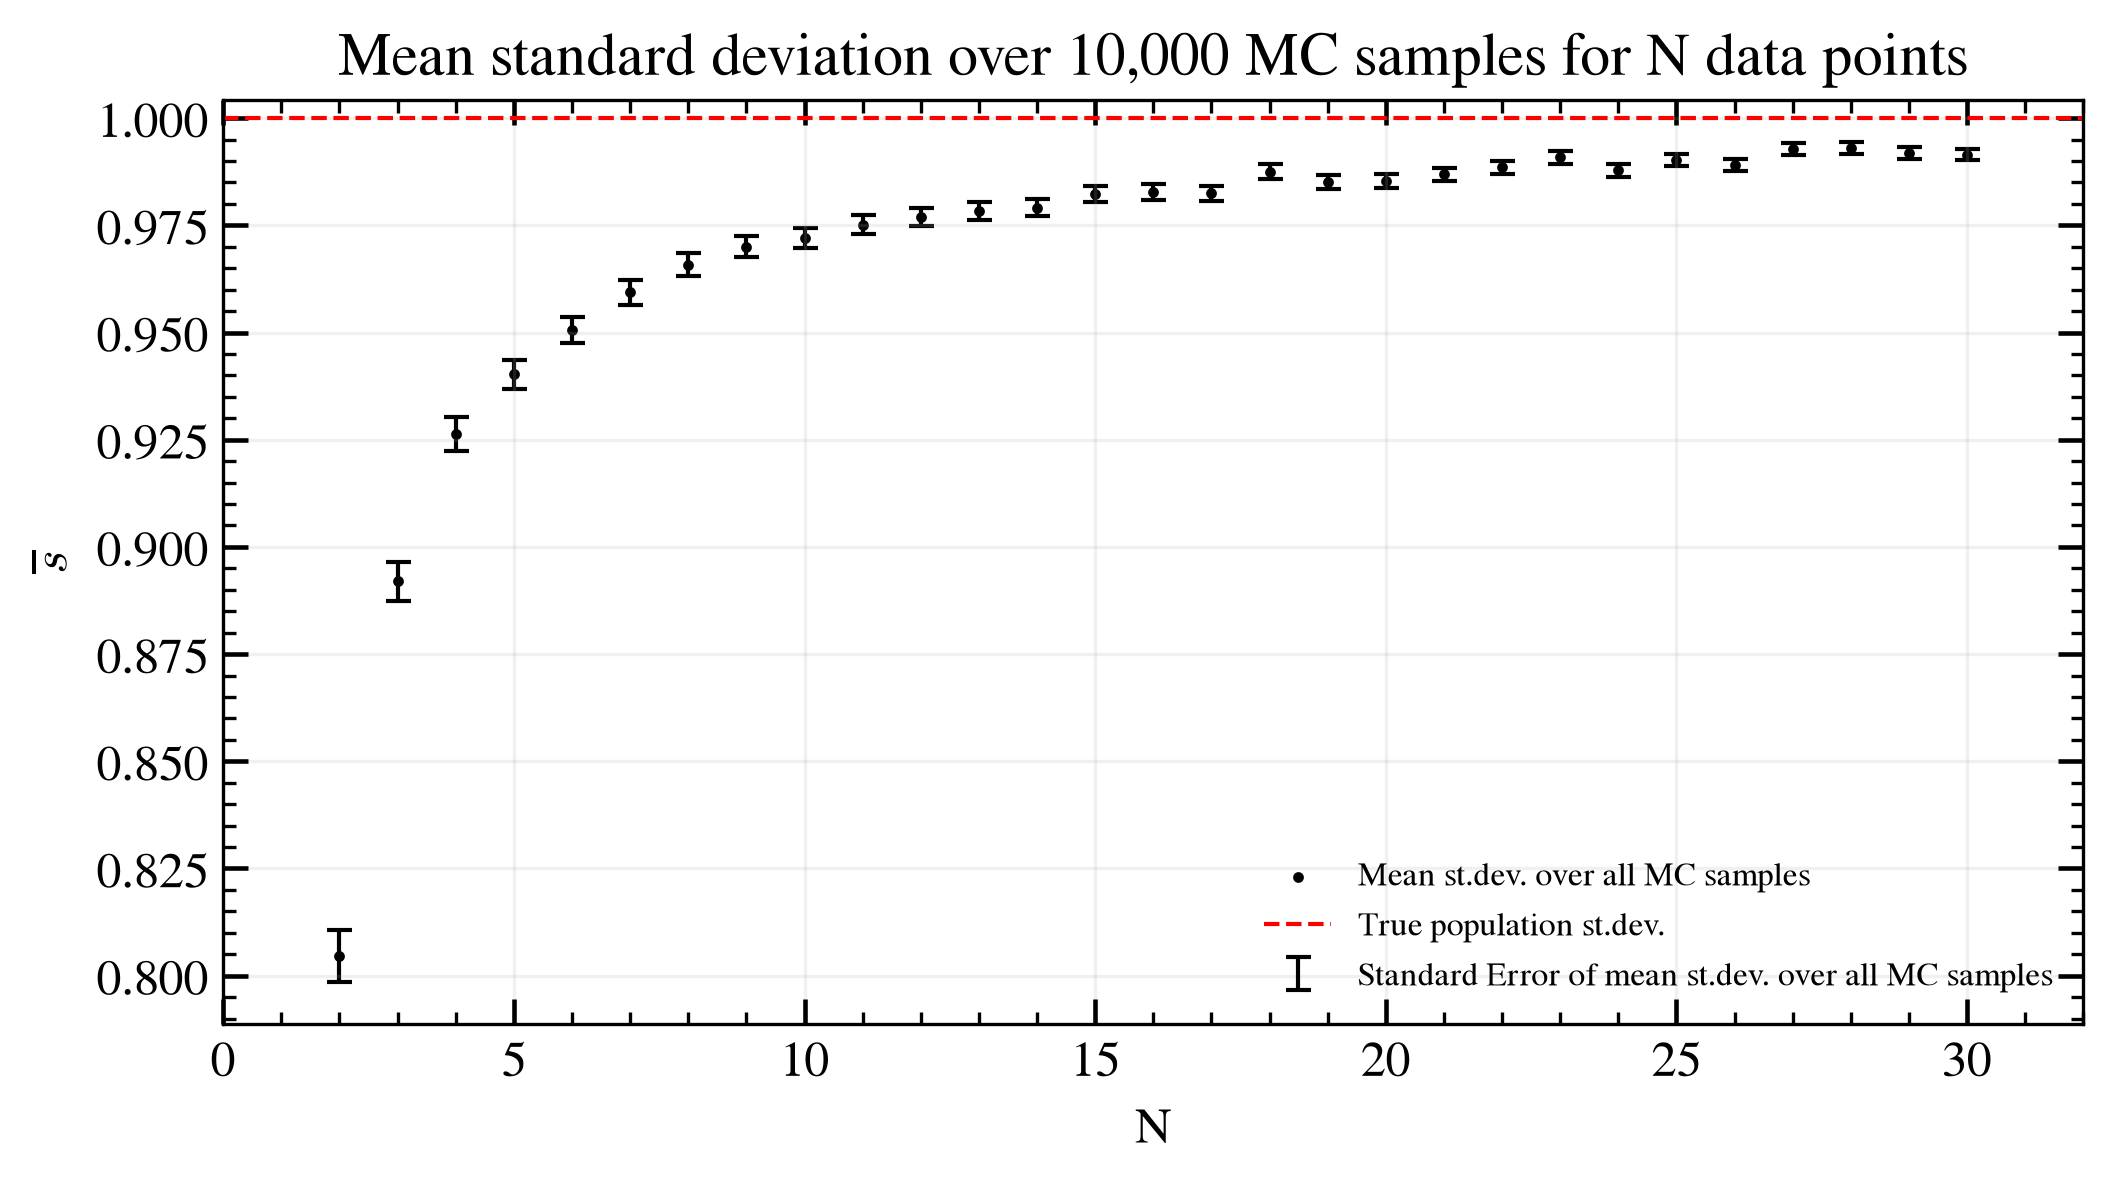

In [19]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('N')
ax.set_ylabel(r'$\overline{s}$')
ax.set_title("Mean standard deviation over 10,000 MC samples for N data points")
ax.set_xlim(0,32)
# ax.set_ylim(0.95,1.05)

ax.scatter(N_array, means_of_estimates_of_std, marker='.', s = 10, label="Mean st.dev. over all MC samples", color='black')

ax.errorbar(N_array, means_of_estimates_of_std, 
    yerr=standard_errors_of_means_of_estimates_of_std,
    fmt="none",
    capsize=3,
    lw = 1.0, 
    label="Standard Error of mean st.dev. over all MC samples",
    zorder= -3, 
    color = 'black'
)

ax.axhline(y=1, color= 'red', ls='dashed', label = 'True population st.dev.', lw = 1.0)    # true population stdev is 1

ax.legend(frameon=False, fontsize=8, loc='best')

### Step 6

In [20]:
data = np.asarray(means_of_estimates_of_std)
model = np.ones_like(data)
unc = np.asarray(standard_errors_of_means_of_estimates_of_std)

chi2_of_means_of_estimates_of_std = compute_chi2_of_data(data,model,unc)           #gives a singular chi2 value for the fit to the data

dof = len(N_array) - 0                   # dof = N - numbers of parameters = 29 since we have 29 data points and no parameters (model is a constant)

print(f"chi2: {chi2_of_means_of_estimates_of_std}")
print(f"reduced chi2: {compute_reduced_chi2(chi2_of_means_of_estimates_of_std, dof=dof)}")        

pval = scipy.stats.chi2.sf(chi2_of_means_of_estimates_of_std, dof)
print(f"p value: {pval:3e}") 


chi2: 4610.530779497663
reduced chi2: 158.98381998267806
p value: 0.000000e+00


In [21]:
# Goodness of fit
if pval < 0.05:         # reject H0 that data and model are the same
    print(f'This is not a good fit. With a p = {pval:2f} < 0.05, we must reject the prediction that the data and the model are equal.')

if pval >= 0.05:         # reject H0 that data and model are the same
    print(
        f'This is a good fit. With a p = {pval:2f} >= 0.05, we do not have enough evidence to reject the prediction that the data and the model are equal.' ,
        f'\nThus we can say this is a statistically acceptable fit and that the simulated results are consistent with it.'
    )

This is not a good fit. With a p = 0.000000 < 0.05, we must reject the prediction that the data and the model are equal.


### Explanation

The results for the sample standard deviation $s$ are different than for the sample variance $s^2$. The sample variance was an unbiased estimator but its square root, the sample standard deviation is biased since it underestimates the true population standard deviation on average. This is because 

\begin{equation*}
    E[\sqrt{s^2}] \neq \sqrt{E[s^2]}
\end{equation*}
and the fact that the square root function is concave: 
\begin{equation*}
    E[s] = E[\sqrt{s^2}] \lt \sqrt{E[s^2]} = \sigma
\end{equation*}
thus taking the root of an unbiaased variance estimator will not result in an unbiased standard deviation estimator. 

 From the MC simulation, we can see that the mean sample standard deviation is consistently below the true population standard deviation across all N's. Unlike for the variance, a chi-squared fit allows us to reject the prediction that the simulated data and the true value are the same, supporting evidence for the sample standard deviation as a biased estimator.  

## Q4

Repeat Q1 but calculate the sample _median_ instead of the sample variance.

Then calculate the mean and variance of the median over all the $M$ MC samples, i.e the mean and variance of the sampling distribution.

Plot the __ratio__ of the MC-estimated variance of the _median_ to the theoretical expectation for variance of the _mean_, as a function of $N$ from 5 to 500 (in steps of 20 or 25, say).

b) What is the asymptotic of this ratio for large $N$? Discuss the pros and cons of medians vs. means for the general case (i.e. the underlying distribution could be Gaussian or not).

### Step 1 (Reset M and N)

In [22]:
def compute_median_of_sample(data):
    med = np.median(data)
    
    return med 

In [23]:
M = 10000       # Number of samples to be drawn, we draw M times a sample containing N data points taken from N~N(0,1)

# N_array = np.linspace(2, 30, num=29, dtype=int)
N_array = np.append(np.arange(5, 501, 25), 500)

### Step 2 and 3 

In [24]:
estimates_of_median = []          # holds the median estimated by each individual 10000 runs with N data points, for each N                            # shape (29, 10000)

for N in N_array:
    median_estimates = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_median_of_sample, M, N, rng)      # shape (10000,), contains 10000 median values for a given N 
    estimates_of_median.append(median_estimates)

print(estimates_of_median)        # array of 10000 s values for each N

[array([-0.92920247, -0.3984013 , -0.2694844 , ...,  0.67713584,
       -0.91349662,  0.44293165], shape=(10000,)), array([ 0.04006798,  0.26682393, -0.30544664, ...,  0.21086511,
       -0.26965635, -0.09418604], shape=(10000,)), array([-0.20224409, -0.18934488,  0.23855472, ...,  0.02644537,
        0.15575421, -0.19551367], shape=(10000,)), array([-0.04811293,  0.06678139, -0.04174678, ..., -0.01594413,
       -0.08303243, -0.04492929], shape=(10000,)), array([ 0.04736213, -0.06643195,  0.16147712, ...,  0.03469224,
        0.01734847, -0.04867545], shape=(10000,)), array([-0.09494466, -0.00640838, -0.00633145, ...,  0.03670111,
       -0.00577701,  0.0521764 ], shape=(10000,)), array([ 0.05583865, -0.17504181, -0.11539414, ...,  0.05842985,
       -0.00615595, -0.12412785], shape=(10000,)), array([-0.0417913 , -0.01868811, -0.02217989, ..., -0.08922607,
        0.06806823,  0.10472028], shape=(10000,)), array([-0.04370116,  0.13596117, -0.09789465, ...,  0.02389864,
       -0.12206

### Step 4

In [25]:
means_of_estimates_of_median = []      # holds the mean of all 10000 medians computed for a given N                  # shape (29, 1)
for estimates in estimates_of_median: 
    mean = np.mean(estimates)           # computes the mean of all 10000 medians          # shape (1,)
    means_of_estimates_of_median.append(mean)   

variances_of_estimates_of_median = []  # holds the median of all the 10000 medians computed for a given N          # shape (29, 1)
for estimates in estimates_of_median:
    var = np.var(estimates, ddof=1)                 # Bessel Correction Factor
    variances_of_estimates_of_median.append(var)

print(means_of_estimates_of_median)            # array of the avg of all 10000 s2 values for a given N     
print()
print(variances_of_estimates_of_median)        # array of the s2 of all 10000 s2 values for a given N 

[np.float64(0.004989264577171165), np.float64(-0.002038275191850938), np.float64(-0.0008258368125826051), np.float64(0.0006959140674201696), np.float64(-0.0016315741801538855), np.float64(0.0008309138092359895), np.float64(-0.002927433212536117), np.float64(-0.00037846428521846035), np.float64(-0.000974280723556478), np.float64(-0.0005424331030199711), np.float64(-0.0004121411368173858), np.float64(0.0013672682005122952), np.float64(0.0004517420375365522), np.float64(0.000606734863611341), np.float64(0.00029566464336190304), np.float64(0.0007021632294939861), np.float64(-0.0008222861177203356), np.float64(-0.00015220306195007827), np.float64(0.0002439507583691416), np.float64(3.273205684509761e-05), np.float64(-0.0004889735901168291)]

[np.float64(0.28794814037648553), np.float64(0.04971673165006777), np.float64(0.028832277773932647), np.float64(0.019026149324442836), np.float64(0.014853584041058618), np.float64(0.011968074469663336), np.float64(0.010102572215388263), np.float64(0.0087

### Step 5

In [26]:
standard_errors_of_means_of_estimates_of_median = []              # holds the stderr for each median        # shape (29, 1)

for var in variances_of_estimates_of_median:
    stderr = compute_standard_error_of_sample(var, N=M)             # computes the std err in the mean of the medians -> we computed the avg of all 10000 m values so N=10000
    standard_errors_of_means_of_estimates_of_median.append(stderr)

print(standard_errors_of_means_of_estimates_of_median)            # array of stderr for each mean of median     # shape (29 , 1)

[np.float64(0.005366079950732057), np.float64(0.002229724907921777), np.float64(0.0016980070015736874), np.float64(0.0013793530847626663), np.float64(0.0012187528068094292), np.float64(0.0010939869500895948), np.float64(0.0010051155264639117), np.float64(0.0009342233000293003), np.float64(0.0008814806942285421), np.float64(0.0008325297981856822), np.float64(0.0007850081847075257), np.float64(0.0007473851697883128), np.float64(0.0007170782957488902), np.float64(0.0006890968858854805), np.float64(0.0006668011042729183), np.float64(0.0006446235593298915), np.float64(0.000620655890709805), np.float64(0.0006040313518494774), np.float64(0.0005881004643633715), np.float64(0.0005644937018355114), np.float64(0.0005528614694171645)]


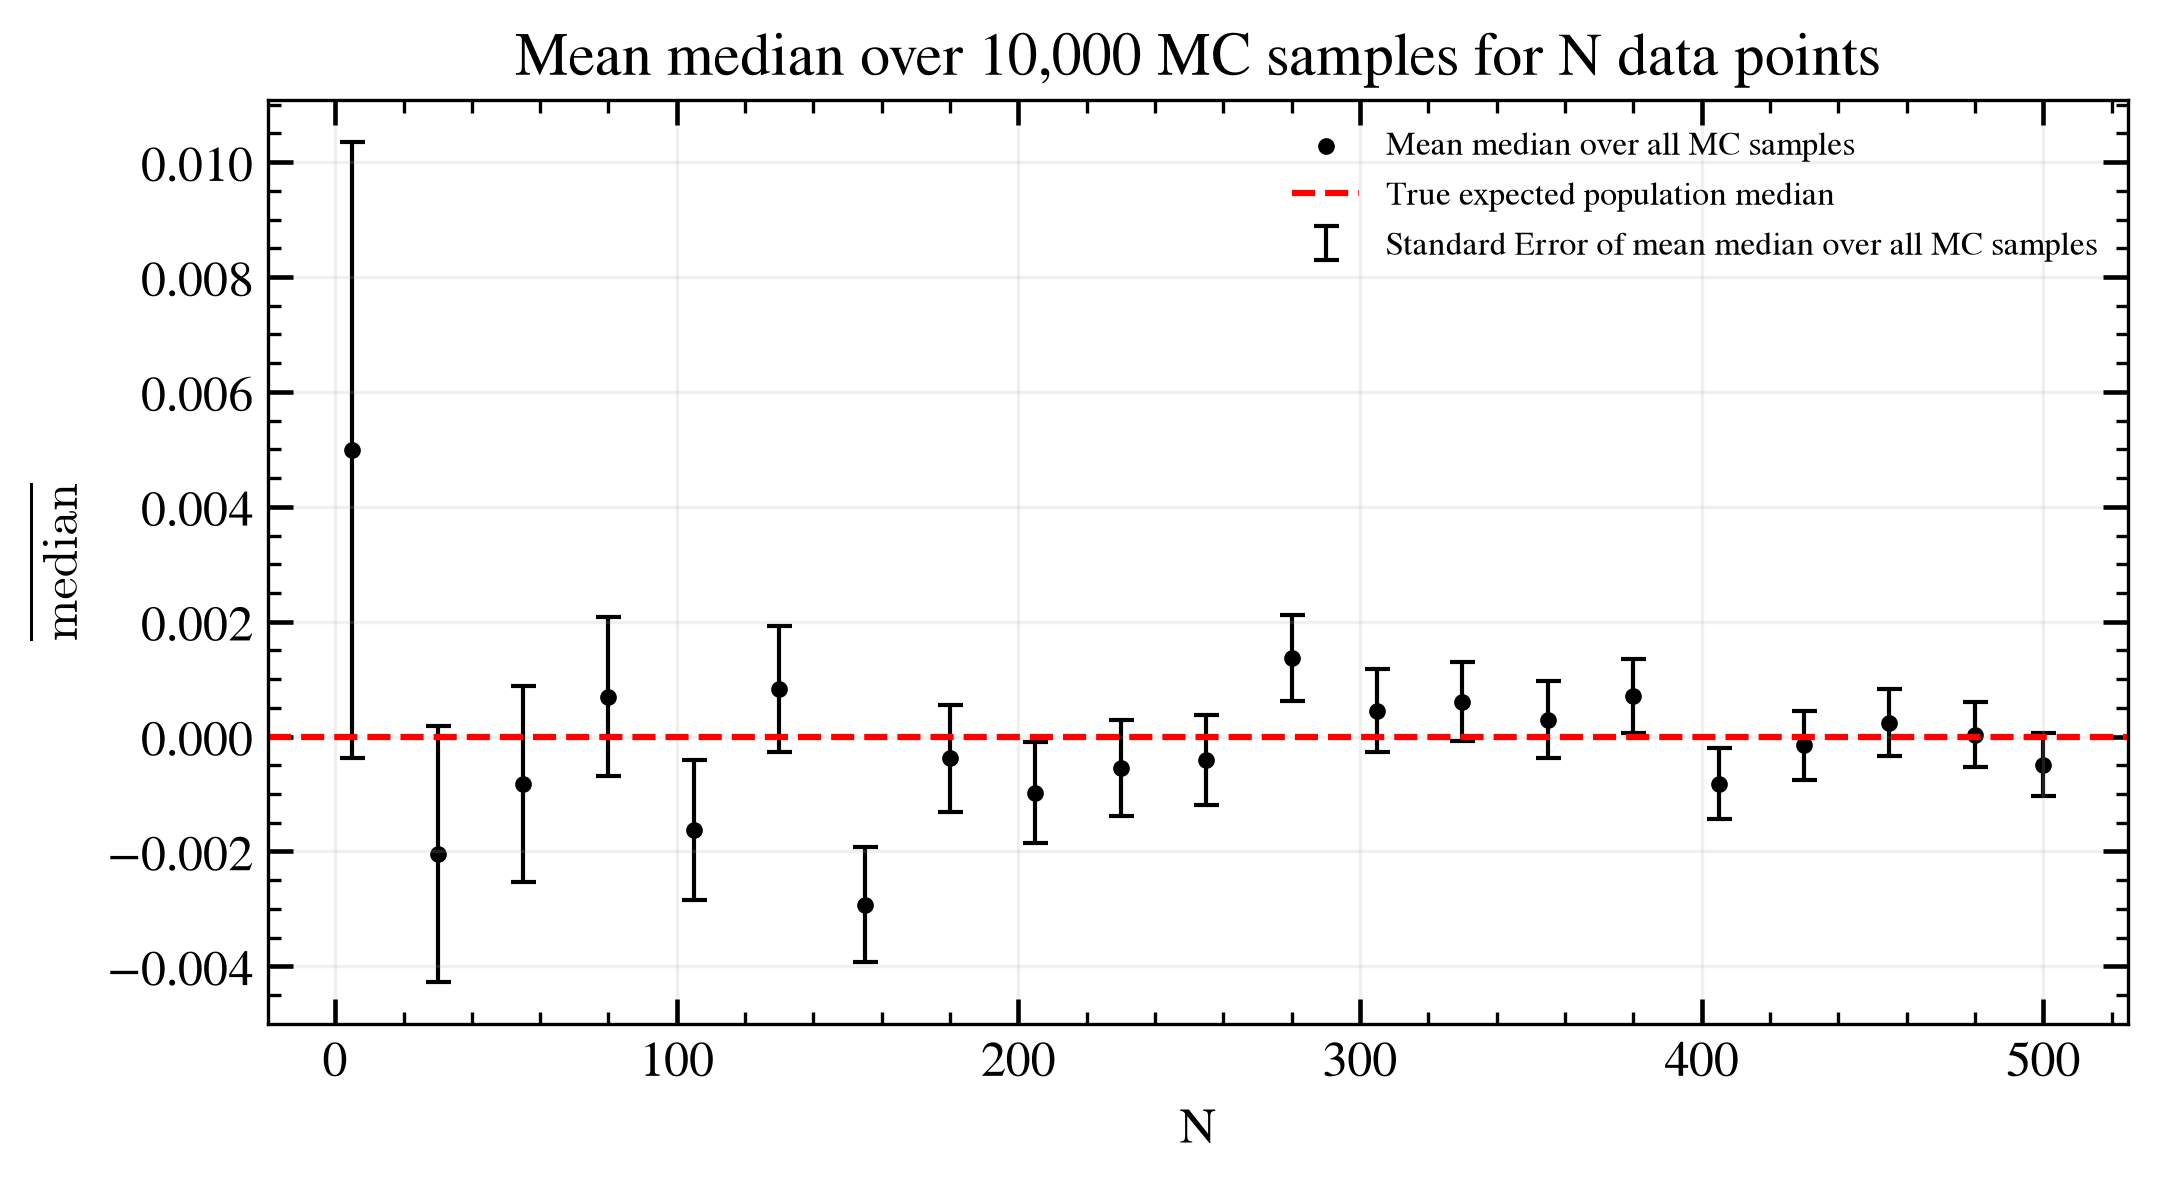

In [27]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('N')
ax.set_ylabel(r'$\overline{\rm median}$')
ax.set_title("Mean median over 10,000 MC samples for N data points")
# ax.set_xlim(0,32)
# ax.set_ylim(0.95,1.05)

ax.scatter(N_array, means_of_estimates_of_median, marker='.', label="Mean median over all MC samples", color='black')

ax.errorbar(N_array, means_of_estimates_of_median, 
    yerr=standard_errors_of_means_of_estimates_of_median,
    fmt="none",
    capsize=3,
    lw = 1.0, 
    label="Standard Error of mean median over all MC samples",
    zorder= -3, 
    color = 'black'
)

ax.axhline(y=0, color= 'red', ls='dashed', label = 'True expected population median')    # True median for a standard gaussian is zero

ax.legend(frameon=False, fontsize=8, loc='best')

### Step 6 

In [28]:
data = np.asarray(means_of_estimates_of_median)
model = np.zeros_like(data)     
unc = np.asarray(standard_errors_of_means_of_estimates_of_median)

chi2_of_means_of_estimates_of_median = compute_chi2_of_data(data,model,unc)           #gives a singular chi2 value for the fit to the data

dof = len(N_array) - 0                   # dof = N - numbers of parameters = 29 since we have 29 data points and no parameters (model is a constant)

print(f"chi2: {chi2_of_means_of_estimates_of_median}")
print(f"reduced chi2: {compute_reduced_chi2(chi2_of_means_of_estimates_of_median, dof=dof)}")        

pval = scipy.stats.chi2.sf(chi2_of_means_of_estimates_of_median, dof)
print(f"p value: {pval}") 


chi2: 23.807405655660915
reduced chi2: 1.1336859836029007
p value: 0.3024835879638654


In [29]:
# Goodness of fit
if pval < 0.05:         # reject H0 that data and model are the same
    print(f'This is not a good fit. With a p = {pval:2f} < 0.05, we must reject the prediction that the data and the model are equal.')

if pval >= 0.05:         # reject H0 that data and model are the same
    print(
        f'This is a good fit. With a p = {pval:2f} >= 0.05, we do not have enough evidence to reject the prediction that the data and the model are equal.' ,
        f'\nThus we can say this is a statistically acceptable fit and that the simulated results are consistent with it.'
    )

This is a good fit. With a p = 0.302484 >= 0.05, we do not have enough evidence to reject the prediction that the data and the model are equal. 
Thus we can say this is a statistically acceptable fit and that the simulated results are consistent with it.


### Plot

Theoretical variance of the sample mean is 

\begin{equation*}
    \sigma^2_{\bar{x}} = \frac{\sigma^2}{N}
\end{equation*}

where $\sigma = 1$ so simply $1/N$. 

In [30]:
theoretical_variance_of_mean = 1.0 / N_array

variance_ratio = np.asarray(variances_of_estimates_of_median) / np.asarray(theoretical_variance_of_mean)

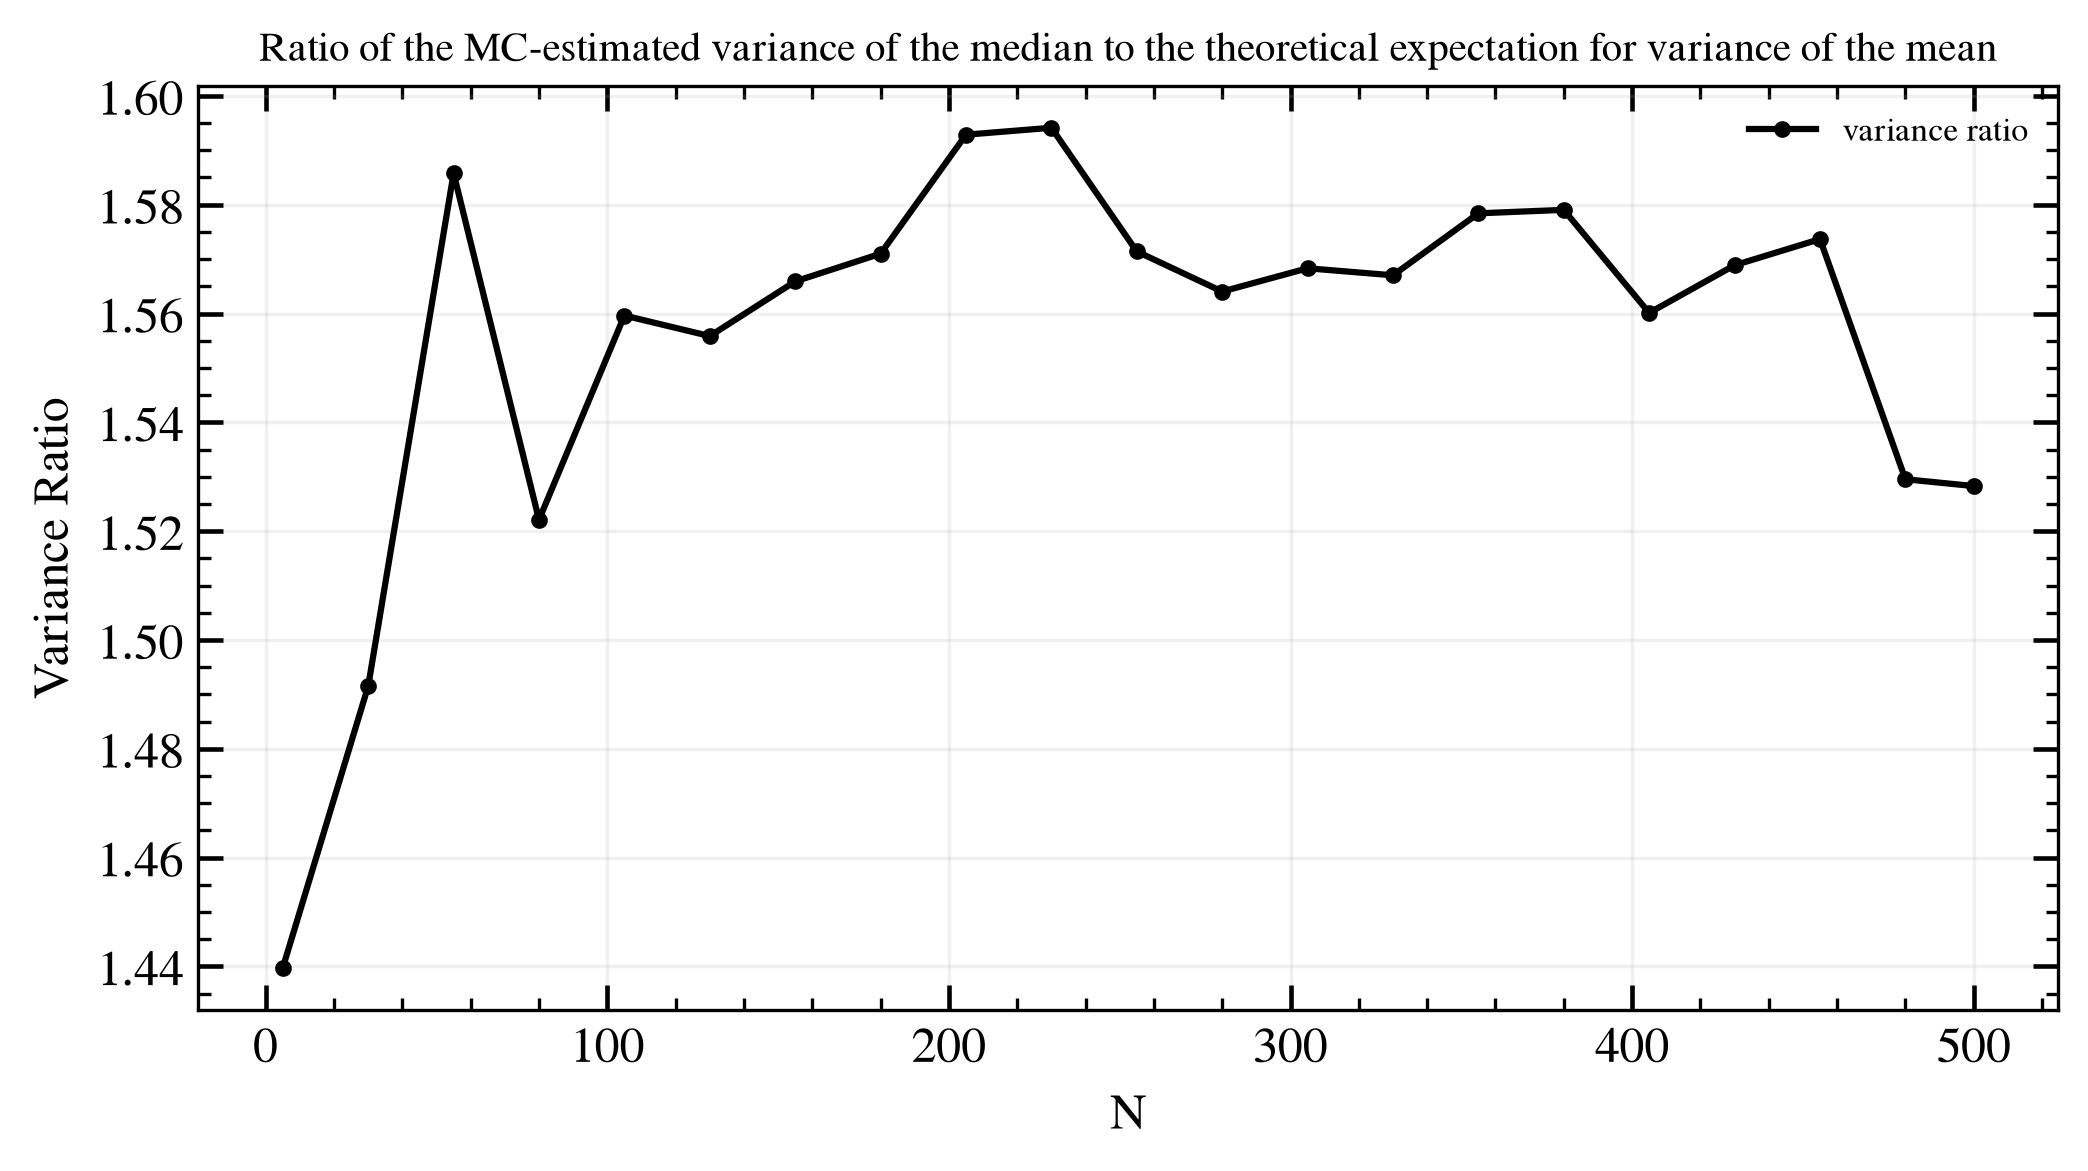

In [31]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('N')
ax.set_ylabel('Variance Ratio')
ax.set_title("Ratio of the MC-estimated variance of the median to the theoretical expectation for variance of the mean", fontsize = 10)
# ax.set_xlim(0,32)
# ax.set_ylim(0.95,1.05)

ax.plot(N_array, variance_ratio, marker='.', label="variance ratio", color='black')

ax.legend(frameon=False, fontsize=8, loc='best')

### Part b)

For a population with median $m$ and probability density at the median $= p(m)$, the variance is roughly

\begin{equation*}
    \mathrm{var(sample~median)} \approx \frac{1}{4Np^2(m)}
\end{equation*}

and for a standard Gaussian the $\rm median = mean = \mu $ and the probability density at $\mu$ is given by: 

\begin{equation*}
    f(\mu) = \frac{1}{\sigma\sqrt{2\pi}}
\end{equation*}
such that we obtain 

\begin{equation*}
    \mathrm{var(sample~median)} \approx \frac{1}{4N \bigg(\frac{1}{\sigma \sqrt{2\pi}} \bigg)^2 } \approx \frac{\pi \sigma^2}{2N}
\end{equation*}

Taking the ratio of this and the variance of the sample mean $\mathrm{var}(\bar{x}) \equiv \frac{\sigma^2}{N}$ we find that 

\begin{equation*}
    \frac{\mathrm{var(sample~median)}}{\mathrm{var(sample~mean)}} = \frac{\frac{\pi \sigma^2}{2N}}{\frac{\sigma^2}{N}} = \frac{\pi}{2} \approx 1.571...
\end{equation*}

as $N \rightarrow \infty$. In other words, for Gaussian data, the ratio approaches $\pi/2$ as sample size increases.

The mean uses the magnitude of every observation, making it useful whenthe quantity of interest is the arithmetic average. However, this also makes it sensitive to outliers: a single extreme observation can shift the mean substantially. For some heavy-tailed distributions, the population mean may not truly exist.

The median identifies the 50th percentile and is robust to extreme values because it depends on the ordering of observations rather than their exact magnitudes. This can make it a useful measure of typical values for skewed data or data containing outliers. However, it does not fully reflect changes in the magnitudes of observations and may have greater sampling variability than the mean, depending on the distribution.

For asymmetric distributions, the population mean and median generally differ, so they estimate different quantities. Neither is universally better and the choice depends on the underlying distribution, the presence of outliers, and whether we want to describe the arithmetic average or the middle value given the context.